In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
import pandas as pd
import itertools
# Reset to the default Matplotlib color cycle
plt.rcParams['axes.prop_cycle'] = plt.rcParamsDefault['axes.prop_cycle']

In [2]:
params = np.array([
[20.038889, 0.046546, 0.099987] ,
[38.048132, 0.039159, 0.099992] ,
[56.073707, 0.036011, 0.099997] ,
[74.048116, 0.012213, -0.066522] ,
[91.954087, 0.017902, 0.025191] ,
[110.019239, 0.014185, 0.020842] ,
[127.991742, 0.011844, 0.018618] ,
[146.03049, 0.009053, -0.061374] ,
[164.016171, 0.008872, 0.014558] ,
[181.995486, 0.00788, 0.01313] ,
[199.990787, 0.007086, 0.011958] ,
[26.087381, 0.0438, 0.075696] ,
[44.039347, 0.032457, 0.024913] ,
[62.046102, 0.035412, 0.099981] ,
[80.069161, 0.03241, 0.074396] ,
[97.924358, 0.01639, 0.024615] ,
[116.07446, 0.013298, 0.020027] ,
[134.048443, 0.011206, 0.017697] ,
[151.979515, 0.009692, 0.015716] ,
[170.003515, 0.009972, 0.020606] ,
[188.012653, 0.007595, 0.012713] ,
[32.042591, 0.09333, 0.069214] ,
[50.071105, 0.027333, 0.027392] ,
[68.030039, 0.012782, -0.067882] ,
[86.113746, 0.019828, 0.02556] ,
[104.06749, 0.015099, 0.022578] ,
[121.914216, 0.012549, 0.019394] ,
[140.027475, 0.010659, 0.016998] ,
[158.04063, 0.00926, 0.015102] ,
[175.997357, 0.008188, 0.013583] ,
[194.002728, 0.007333, 0.012326] ,

[21.06029, 0.045725, 0.099881] ,
[27.083294, 0.043358, 0.074745] ,
[33.105505, 0.091792, 0.066081] ,
[39.035191, 0.038949, 0.099997] ,
[45.062483, 0.031494, 0.025513] ,
[50.944819, 0.036165, 0.049931] ,
[57.030494, 0.032624, 0.052296] ,
[63.025827, 0.020617, 0.016805] ,
[69.04612, 0.018133, 0.01565] ,
[75.000203, 0.012103, -0.06634] ,
[81.089294, 0.02179, 0.025784] ,
[87.013823, 0.019456, 0.025483] ,
[93.001314, 0.017619, 0.02511] ,
[99.038245, 0.016162, 0.024422] ,
[105.048358, 0.014932, 0.022144] ,
[111.03148, 0.014008, 0.020649] ,
[117.035911, 0.013183, 0.019927] ,
[122.963662, 0.012429, 0.019284] ,
[129.061123, 0.011731, 0.018432] ,
[134.942757, 0.011117, 0.017584] ,
[141.014706, 0.010567, 0.016879] ,
[146.985329, 0.01008, 0.016254] ,
[153.004097, 0.009619, 0.015611] ,
[159.054605, 0.00856, -0.059946] ,
[164.993223, 0.010326, 0.021263] ,
[170.994761, 0.008461, 0.013986] ,
[177.010894, 0.008138, 0.013506] ,
[182.993735, 0.007833, 0.013058] ,
[188.993283, 0.007552, 0.012654] ,
[194.992779, 0.007293, 0.012272] ,

[22.046788, 0.044781, 0.099934] ,
[28.071431, 0.043048, 0.073693] ,
[34.092377, 0.090275, 0.06309] ,
[40.039522, 0.038721, 0.09999] ,
[46.051223, 0.030666, 0.026049] ,
[52.097914, 0.036428, 0.099977] ,
[58.040789, 0.035749, 0.099997] ,
[64.025165, 0.020284, 0.016651] ,
[70.046881, 0.017859, 0.015781] ,
[76.063045, 0.024125, 0.025925] ,
[82.103031, 0.0213, 0.025657] ,
[87.914703, 0.01914, 0.025431] ,
[93.900851, 0.017377, 0.02504] ,
[99.900843, 0.01595, 0.02413] ,
[106.078853, 0.014788, 0.021797] ,
[112.107456, 0.013826, 0.02052] ,
[118.097628, 0.013051, 0.019894] ,
[123.924681, 0.012318, 0.019155] ,
[130.090662, 0.01162, 0.018284] ,
[136.09185, 0.01101, 0.01746] ,
[142.023622, 0.010486, 0.016785] ,
[148.02226, 0.009977, 0.016129] ,
[153.997652, 0.009537, 0.015498] ,
[160.012976, 0.009127, 0.014925] ,
[165.97014, 0.008755, 0.014387] ,
[172.010156, 0.008402, 0.013907] ,
[177.992806, 0.008084, 0.013432] ,
[183.995702, 0.007784, 0.012991] ,
[190.012319, 0.007507, 0.012585] ,
[196.000313, 0.009444, 0.022985] ,

[23.090014, 0.045329, 0.080106] ,
[29.106397, 0.042434, 0.073266] ,
[35.05881, 0.074662, 0.083786] ,
[41.09749, 0.038374, 0.099992] ,
[47.039562, 0.029645, 0.026575] ,
[53.091718, 0.03514, 0.050526] ,
[59.081764, 0.035759, 0.09999] ,
[65.038863, 0.035071, 0.099985] ,
[71.045176, 0.017628, 0.015557] ,
[77.115068, 0.023718, 0.026113] ,
[83.069728, 0.020976, 0.025658] ,
[88.916175, 0.018837, 0.025429] ,
[94.928093, 0.017117, 0.02499] ,
[100.952671, 0.015752, 0.024012] ,
[107.082495, 0.014592, 0.021466] ,
[113.085998, 0.013723, 0.020426] ,
[118.969003, 0.012926, 0.019723] ,
[124.957118, 0.012183, 0.018972] ,
[130.99199, 0.011526, 0.018137] ,
[137.097253, 0.010921, 0.017324] ,
[142.980871, 0.010398, 0.016685] ,
[149.003567, 0.009909, 0.016017] ,
[155.027173, 0.009474, 0.015419] ,
[161.011636, 0.009063, 0.014843] ,
[167.008638, 0.008688, 0.014313] ,
[172.995679, 0.008348, 0.013803] ,
[179.01285, 0.008027, 0.013347] ,
[184.996886, 0.007737, 0.012918] ,
[191.00476, 0.007463, 0.012516] ,
[197.014357, 0.007207, 0.012137] ,

[24.081986, 0.044963, 0.078017] ,
[30.055457, 0.042266, 0.073187] ,
[36.033267, 0.073741, 0.083667] ,
[42.034664, 0.03477, 0.023055] ,
[48.011169, 0.037049, 0.099941] ,
[54.093678, 0.0345, 0.050824] ,
[60.105166, 0.035588, 0.099996] ,
[66.032152, 0.019442, 0.016426] ,
[72.046013, 0.01233, -0.066785] ,
[78.105623, 0.033845, 0.099961] ,
[84.096123, 0.020569, 0.025607] ,
[89.918767, 0.018506, 0.025369] ,
[95.913976, 0.016875, 0.024903] ,
[102.050682, 0.015479, 0.023527] ,
[108.085486, 0.014447, 0.021257] ,
[114.092198, 0.013576, 0.020296] ,
[119.919454, 0.012801, 0.019631] ,
[125.910637, 0.012082, 0.018866] ,
[132.061557, 0.011413, 0.018001] ,
[138.075076, 0.010834, 0.017214] ,
[144.026251, 0.010313, 0.016551] ,
[150.054085, 0.009842, 0.015928] ,
[156.015515, 0.0094, 0.015292] ,
[162.006963, 0.009001, 0.014747] ,
[167.990436, 0.008635, 0.014232] ,
[173.991666, 0.008293, 0.013735] ,
[180.0098, 0.00798, 0.013271] ,
[186.001955, 0.00769, 0.012857] ,
[192.00798, 0.007418, 0.012453] ,
[197.986209, 0.021154, 0.073061] ,

[25.071977, 0.044541, 0.076587] ,
[31.086764, 0.078962, 0.091107] ,
[36.921568, 0.073024, 0.082865] ,
[43.08375, 0.033597, 0.02405] ,
[49.077318, 0.02798, 0.027318] ,
[55.029341, 0.036227, 0.099887] ,
[61.052354, 0.035506, 0.099969] ,
[67.038538, 0.012788, -0.067619] ,
[73.044719, 0.016828, 0.015019] ,
[79.094371, 0.022635, 0.025894] ,
[85.036438, 0.020148, 0.025575] ,
[90.946114, 0.018181, 0.025234] ,
[96.921653, 0.016621, 0.024754] ,
[103.078416, 0.015238, 0.023036] ,
[109.08795, 0.01431, 0.021065] ,
[115.061517, 0.013438, 0.020179] ,
[121.011781, 0.012666, 0.019508] ,
[127.015693, 0.011954, 0.018674] ,
[133.043598, 0.011308, 0.017809] ,
[138.969127, 0.010751, 0.017086] ,
[145.009159, 0.010234, 0.01643] ,
[150.993694, 0.009764, 0.015833] ,
[156.998377, 0.009332, 0.015191] ,
[163.010766, 0.008453, -0.059712] ,
[169.04253, 0.010055, 0.020801] ,
[175.001289, 0.00824, 0.013667] ,
[181.016743, 0.00793, 0.013205] ,
[186.995923, 0.007643, 0.012787] ,
[192.98821, 0.007377, 0.012392] ,
[198.984102, 0.007127, 0.012015] ,
])
f_200 = np.array([
-1.0031736, -1.24348592, -1.55477195, -1.42913993 ,
-3.05403662, -2.35164035, -3.00235552, -3.93956322 ,
-3.72838862, -4.27913881, -4.27838585 ,
-1.07267743, -1.08462355, -1.63755399, -1.87824453 ,
-2.46420535, -2.85255132, -3.05405663, -3.33374657 ,
-3.69774262, -4.41989511 ,
-0.9808784, -1.13430486, -1.30829823, -2.25913831 ,
-2.14803854, -3.17562185, -3.28051597, -3.49232032 ,
-3.9805936, -4.3566619 ,

-1.05179309, -1.02337647, -1.12122035, -1.3183587 ,
-1.11993671, -1.26420002, -1.37553235, -1.06935308 ,
-1.22318469, -1.45132467, -1.72916331, -2.38215357 ,
-3.03379809, -2.36737945, -2.15200289, -2.41921061 ,
-2.9416359, -3.15875687, -2.9915114, -3.08268687 ,
-3.30678302, -3.33609462, -3.34895066, -3.97557957 ,
-3.63009924, -3.84467749, -4.01418856, -4.33576188 ,
-4.42988437, -4.34643608 ,

-1.07459902, -0.96111974, -1.15594856, -1.3849363 ,
-1.1436341, -1.44856253, -1.60849866, -1.09519211 ,
-1.24730539, -1.3549283, -1.81811161, -2.51397416 ,
-2.9484976, -2.30360374, -2.1711177, -2.49694869 ,
-3.02777478, -3.13026216, -2.98986876, -3.12529529 ,
-3.32445603, -3.32456116, -3.36926407, -3.5822038 ,
-3.77860956, -3.85557768, -4.05555222, -4.37603814 ,
-4.42835964, -3.7815885 ,

-1.084089, -0.88570813, -1.16035349, -1.44392102 ,
-1.15531963, -1.49813669, -1.62573261, -1.62809536 ,
-1.26845614, -1.4253146, -1.91094629, -2.6708571 ,
-2.81629662, -2.23938853, -2.2027174, -2.57665644 ,
-3.09306813, -3.09261573, -2.9954503, -3.16765535 ,
-3.33681194, -3.32130237, -3.3922841, -3.62587951 ,
-3.80036261, -3.87652861, -4.10096654, -4.39506913 ,
-4.41267933, -4.34054504 ,

-1.10740845, -0.81446558, -1.13757244, -0.99580117 ,
-1.41908786, -1.53179734, -1.63795183, -1.14763475 ,
-1.38706916, -1.78595259, -2.01774778, -2.83096465 ,
-2.68667231, -2.189611, -2.24516398, -2.66480193 ,
-3.14303675, -3.05909242, -3.00830251, -3.20852524 ,
-3.34581571, -3.31840714, -3.42006691, -3.66546283 ,
-3.81965209, -3.9089449, -4.15554908, -4.40146334 ,
-4.39033218, -4.4418318 ,

-1.10328382, -0.91000845, -1.08363607, -1.04467733 ,
-1.14867203, -1.51719893, -1.64014914, -1.28841948 ,
-1.30657672, -1.56840205, -2.12536225, -2.97491912 ,
-2.56719719, -2.15872855, -2.29661064, -2.75524557 ,
-3.17287173, -3.02344925, -3.0276983, -3.24400258 ,
-3.34663268, -3.32367172, -3.45104416, -4.21035429 ,
-3.68972539, -3.94367528, -4.21753438, -4.40900027 ,
-4.37020936, -4.30560441 ,
])
df = pd.DataFrame(data=np.hstack((params, f_200.reshape(-1,1))),
                  columns=['tg', 'amp', 'detune', 'f_200'])
df_sorted = df.sort_values(by='tg')
df_sorted

,tg,amp,detune,f_200
0,20.038889,0.046546,0.099987,-1.003174
31,21.060290,0.045725,0.099881,-1.051793
61,22.046788,0.044781,0.099934,-1.074599
91,23.090014,0.045329,0.080106,-1.084089
121,24.081986,0.044963,0.078017,-1.107408
...,...,...,...,...
90,196.000313,0.009444,0.022985,-3.781588
120,197.014357,0.007207,0.012137,-4.340545
150,197.986209,0.021154,0.073061,-4.441832
180,198.984102,0.007127,0.012015,-4.305604


In [3]:
# params = np.array([
# [20.038889, 0.046546, 0.099987] ,
# [38.048132, 0.039159, 0.099992] ,
# [56.073707, 0.036011, 0.099997] ,
# [74.048116, 0.012213, -0.066522] ,
# [91.954087, 0.017902, 0.025191] ,
# [110.019239, 0.014185, 0.020842] ,
# [127.991742, 0.011844, 0.018618] ,
# [146.03049, 0.009053, -0.061374] ,
# [164.016171, 0.008872, 0.014558] ,
# [181.995486, 0.00788, 0.01313] ,
# [199.990787, 0.007086, 0.011958] ,
# [26.087381, 0.0438, 0.075696] ,
# [44.039347, 0.032457, 0.024913] ,
# [62.046102, 0.035412, 0.099981] ,
# [80.069161, 0.03241, 0.074396] ,
# [97.924358, 0.01639, 0.024615] ,
# [116.07446, 0.013298, 0.020027] ,
# [134.048443, 0.011206, 0.017697] ,
# [151.979515, 0.009692, 0.015716] ,
# [170.003515, 0.009972, 0.020606] ,
# [188.012653, 0.007595, 0.012713] ,
# [32.042591, 0.09333, 0.069214] ,
# [50.071105, 0.027333, 0.027392] ,
# [68.030039, 0.012782, -0.067882] ,
# [86.113746, 0.019828, 0.02556] ,
# [104.06749, 0.015099, 0.022578] ,
# [121.914216, 0.012549, 0.019394] ,
# [140.027475, 0.010659, 0.016998] ,
# [158.04063, 0.00926, 0.015102] ,
# [175.997357, 0.008188, 0.013583] ,
# [194.002728, 0.007333, 0.012326] ,
# ])
# f_200 = np.array([
# -1.0031736, -1.24348592, -1.55477195, -1.42913993 ,
# -3.05403662, -2.35164035, -3.00235552, -3.93956322 ,
# -3.72838862, -4.27913881, -4.27838585 ,
# -1.07267743, -1.08462355, -1.63755399, -1.87824453 ,
# -2.46420535, -2.85255132, -3.05405663, -3.33374657 ,
# -3.69774262, -4.41989511 ,
# -0.9808784, -1.13430486, -1.30829823, -2.25913831 ,
# -2.14803854, -3.17562185, -3.28051597, -3.49232032 ,
# -3.9805936, -4.3566619 ,
# ])
# df = pd.DataFrame(data=np.hstack((params, f_200.reshape(-1,1))),
#                   columns=['tg', 'amp', 'detune', 'f_200'])
# df_sorted = df.sort_values(by='tg')
# df_sorted

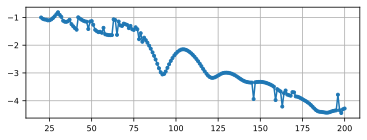

In [4]:
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(df_sorted['tg'], df_sorted['f_200'], '.-')
plt.grid()

In [5]:
cz_se= pd.read_csv('../figure/data/data_cz_3ncut_truc1=300_select.txt')
cz= pd.read_csv('data/data_cz_3ncut_truc1=300.txt')
# # cz_abs_se= pd.read_csv('data/data_cz_3ncut_truc1=300_abs_select.txt')
# # cz_abs= pd.read_csv('data/data_cz_3ncut_truc1=300_abs.txt')
# # params = cz_3ncut_se.to_numpy()[[0, 5, 10, 15, 20, 25, 30],:]
# # cz_old = pd.read_csv('data/data_fig/data_cz_n2_20.txt')
# # pa = np.column_stack((cz_3ncut_se.to_numpy(), np.round(f_noise_9_2us, 8), np.round(f_noise_100_5us, 8), np.round(f_noise_100_50us, 8), np.round(f_ideal_70, 8)))
# # df = pd.DataFrame(pa, columns=['tg', 'drive_amp', 'detune', 'f_300_200_True',
# #                                'f_300_1000_True', 'f_noise_9_2us', 'f_noise_100_5us', 'f_noise_100_50us', 'f_ideal_70'])
# # df.to_csv('data/data_cz_3ncut_truc1=300_select.txt', sep=',', index=False, header=True)
# tg_list = [32, 74, 116, 158, 200]  # Select the first row for testing


In [6]:
f_ideal_1000 = np.array([
-0.74615650, -0.35735157, -0.40215531, -0.56178381 ,
-0.95811679, -1.15564116, -1.03580528, -1.05336740 ,
-1.20356508, -1.32266091, -1.60649343, -2.21255395 ,
-2.86482092, -2.40556149, -2.16238642, -2.38798190 ,
-2.82838483, -3.00699633, -2.94030583, -3.06534253 ,
-3.24019506, -3.25350188, -3.30892131, -3.52221173 ,
-3.72987194, -3.85810978, -4.09601386, -4.33899580 ,
-4.26563472, -4.12619435, -3.94939514 ,
])
f_ideal_1000_npz = np.array([
-0.72049574, -0.33201747, -0.41058575, -0.60643456 ,
-1.01800388, -1.14577047, -1.00875814, -1.03728788 ,
-1.18763931, -1.31333139, -1.59989737, -2.16729271 ,
-2.65364118, -2.32227948, -2.09225387, -2.28806567 ,
-2.71234580, -3.00976953, -2.91097220, -2.96031838 ,
-3.11780820, -3.16594948, -3.16870582, -3.28996270 ,
-3.41174452, -3.49669505, -3.56362582, -3.66449257 ,
-3.72243185, -3.69454265, -3.68364552 ,
])

f_200_tg_0 = np.array([
-1.00355878, -1.24333334, -1.4473779, -1.32371541 ,
-3.05337003, -2.35115076, -3.0037915, -3.34374839 ,
-3.72748311, -4.27900147, -4.27885363 ,
])

f_200_tg_1 = np.array([
-1.07245002, -1.47715479, -1.17681139, -1.64377048 ,
-2.46342492, -2.85278414, -3.05375236, -3.33402596 ,
-3.83755769, -4.41682576 ,
])
f_200_tg_2 = np.array([
-0.97809998, -1.13451877, -1.64766993, -2.2594689 ,
-2.1480107, -3.17578914, -3.28063401, -3.49173382 ,
-3.97910147, -4.35661976 ,
])

f_200_tg_0_bound = np.array([
-1.06064067, -1.5978517, -2.56850942, -1.83120878 ,
-3.05319374, -2.81797385, -3.00280991, -3.34243314 ,
-3.60805005, -4.28042006, -3.89994672 ,
])
f_200_tg_0_mutation = np.array([
-1.00355119, -0.90135328, -1.55282476, -1.32473193 ,
-3.05336354, -2.35154197, -3.00361287, -3.34536466 ,
-3.72859765, -4.28029589, -3.9009206 ,
])
f_200_tg_0_tol = np.array([
-1.00384989, -0.9841791, -1.55494839, -1.42932378 ,
-3.05417588, -2.35227798, -3.00387987, -3.34546797 ,
-3.72885583, -4.2801667, -4.27881127 ,
])

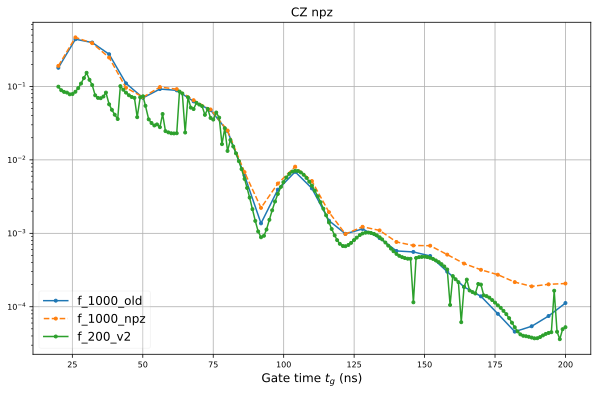

In [7]:

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(cz_se['tg'], 10**f_ideal_1000, '.-',  label=r'f_1000_old')
ax.plot(cz_se['tg'], 10**f_ideal_1000_npz, '.--',  label=r'f_1000_npz')
# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0, 'bs',  label=r'f_200_v1')
# ax.plot(cz_se['tg'][1::3], 10**f_200_tg_1, 'bs')
# ax.plot(cz_se['tg'][2::3], 10**f_200_tg_2, 'bs')
plt.plot(df_sorted['tg'], 10**df_sorted['f_200'], '.-', label=r'f_200_v2')

# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0_bound, '.-',  label=r'f_200_tg_0_bound')
# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0_mutation, 'x-',  label=r'f_200_tg_0_mutation')
# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0_tol, '+-',  label=r'f_200_tg_0_tol')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CZ npz', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

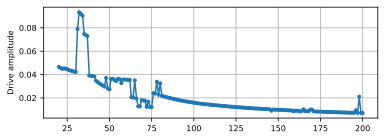

In [11]:
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(df_sorted['tg'], df_sorted['amp'], '.-')
plt.ylabel('Drive amplitude')
plt.grid()

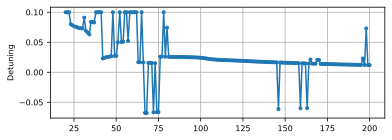

In [10]:
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(df_sorted['tg'], df_sorted['detune'], '.-')
plt.ylabel('Detuning')
plt.grid()

In [4]:

f_ideal_1000 = np.array([
-0.74615650, -0.35735157, -0.40215531, -0.56178381 ,
-0.95811679, -1.15564116, -1.03580528, -1.05336740 ,
-1.20356508, -1.32266091, -1.60649343, -2.21255395 ,
-2.86482092, -2.40556149, -2.16238642, -2.38798190 ,
-2.82838483, -3.00699633, -2.94030583, -3.06534253 ,
-3.24019506, -3.25350188, -3.30892131, -3.52221173 ,
-3.72987194, -3.85810978, -4.09601386, -4.33899580 ,
-4.26563472, -4.12619435, -3.94939514 ,
])

f_ideal_200 = np.array([
-0.78159917, -0.37928767, -0.40229208, -0.62120156 ,
-1.01429717, -1.15662774, -1.03406147, -1.04210110 ,
-1.19694778, -1.32157514, -1.62145519, -2.22775818 ,
-2.83086037, -2.37161712, -2.13345832, -2.37326764 ,
-2.83456922, -3.02253638, -2.94324886, -3.06393585 ,
-3.24121967, -3.25873542, -3.31765727, -3.53659150 ,
-3.74923201, -3.87514321, -4.11269135, -4.35311780 ,
-4.26892569, -4.12712657, -3.94897473 ,
])

f_ideal_150 = np.array([
-0.76881152, -0.36984859, -0.41295294, -0.61347608 ,
-1.01377125, -1.14316594, -1.02452711, -1.05523500 ,
-1.20293350, -1.32196245, -1.63488367, -2.24405173 ,
-2.89094587, -2.40367129, -2.17954057, -2.44128983 ,
-2.93623823, -3.07699610, -2.95304203, -3.07385341 ,
-3.26595818, -3.28755640, -3.34547424, -3.56714873 ,
-3.77679981, -3.89332070, -4.12677649, -4.36339609 ,
-4.27246984, -4.12807124, -3.94919605 ,
])

f_ideal_100 = np.array([
-0.68349027, -0.33709408, -0.41158606, -0.59873989 ,
-1.01269858, -1.15992199, -1.02135877, -1.05012509 ,
-1.20009399, -1.31985603, -1.65091965, -2.27215009 ,
-2.90980841, -2.39850652, -2.17838238, -2.44317103 ,
-2.94222680, -3.08380551, -2.95656037, -3.07866656 ,
-3.27501967, -3.29967433, -3.36134258, -3.58514059 ,
-3.78129524, -3.87401591, -4.07354728, -4.27510950 ,
-4.21617221, -4.10012432, -3.93846721 ,
])

f_ideal_50 = np.array([
-0.20043407, -0.13495554, -0.36554139, -0.55487981 ,
-0.72001995, -0.80073530, -0.80720054, -0.90742430 ,
-1.06937440, -1.19796746, -1.78522631, -2.13335723 ,
-2.12561065, -1.95803223, -2.02231175, -2.33029423 ,
-2.65516134, -2.75010253, -2.73827410, -2.89769950 ,
-3.03533799, -3.05149285, -3.14394746, -3.32489202 ,
-3.45084156, -3.57116809, -3.71696331, -3.84708294 ,
-3.89458272, -3.83157502, -3.75810096 ,
])

f_3us_50 = np.array([
-0.53752376, -0.27835029, -0.43784564, -0.80039438 ,
-1.18175270, -1.15298817, -1.00783759, -1.03663853 ,
-1.16765111, -1.26977020, -1.52700553, -1.92994507 ,
-2.15076128, -2.01817451, -1.89939935, -2.00542444 ,
-2.12283825, -2.13457574, -2.10860848, -2.10931336 ,
-2.11304642, -2.10286195, -2.09106072, -2.08662030 ,
-2.07850574, -2.06688229, -2.05612912, -2.04455749 ,
-2.03099063, -2.01807633, -2.00431118 ,
])
f_30us_50 = np.array([
-0.53971172, -0.27812323, -0.44010660, -0.80945228 ,
-1.20710249, -1.17365071, -1.02111901, -1.05399289 ,
-1.19375173, -1.30577456, -1.62022886, -2.20887961 ,
-2.76293524, -2.35215395, -2.14260630, -2.37613035 ,
-2.75563155, -2.83823536, -2.75815652, -2.82284121 ,
-2.90646480, -2.90270967, -2.91075755, -2.96519146 ,
-2.99432037, -2.99695707, -3.00614004, -3.00637302 ,
-2.98872348, -2.96830316, -2.94198986 ,
])
f_170us_50 = np.array([
-0.53990880, -0.27809543, -0.44031246, -0.81029019 ,
-1.20945565, -1.17554467, -1.02234116, -1.05559934 ,
-1.19621120, -1.30922452, -1.62982599, -2.24617242 ,
-2.90722467, -2.40063824, -2.17350586, -2.43338890 ,
-2.91170534, -3.04013624, -2.92423976, -3.03278164 ,
-3.19026890, -3.19398949, -3.22627985, -3.36896602 ,
-3.47372734, -3.51187681, -3.57812384, -3.61800193 ,
-3.58766312, -3.54403254, -3.48170005 ,
])

f_short_50 = np.array([
-0.53992551, -0.27811146, -0.44036360, -0.81051621 ,
-1.21005738, -1.17608955, -1.02272064, -1.05598635 ,
-1.19680555, -1.31006415, -1.63269287, -2.25796802 ,
-2.96276110, -2.41684142, -2.18312721, -2.45146602 ,
-2.96940032, -3.12094598, -2.98614213, -3.11653506 ,
-3.32020974, -3.32898744, -3.37898327, -3.60826665 ,
-3.82478428, -3.93508488, -4.17276382, -4.41441610 ,
-4.29877380, -4.14218932, -3.95670126 ,
])

f_short_100 = np.array([
-0.91708874, -0.35195516, -0.42570425, -0.58492113 ,
-1.13137251, -1.25663815, -1.05409046, -1.06524111 ,
-1.21212003, -1.32943514, -1.58337829, -2.19980275 ,
-2.92689363, -2.42943079, -2.18329854, -2.44562973 ,
-2.96040574, -3.11839835, -2.98769955, -3.11886844 ,
-3.32623001, -3.33637291, -3.38602618, -3.61780451 ,
-3.83625926, -3.94421892, -4.17907249, -4.41196199 ,
-4.29082455, -4.13303432, -3.94996194 ,
])

f_short_150 = np.array([
-0.76161390, -0.36557958, -0.42666403, -0.66343082 ,
-1.11863325, -1.21089028, -1.03906367, -1.04554105 ,
-1.19706059, -1.32219807, -1.62165190, -2.24056486 ,
-2.91023698, -2.39436306, -2.13839398, -2.38120688 ,
-2.85328702, -3.03782058, -2.94816212, -3.07459019 ,
-3.27228343, -3.29952120, -3.36500407, -3.60210313 ,
-3.82609745, -3.94020142, -4.17719687, -4.41099415 ,
-4.29111780, -4.13325585, -3.95024919 ,
])

f_short_200 = np.array([
-0.75804215, -0.37298379, -0.40972132, -0.62797089 ,
-1.04710494, -1.19021795, -1.03803459, -1.04280161 ,
-1.19707062, -1.32238196, -1.61767880, -2.22722101 ,
-2.87796582, -2.38929525, -2.13161788, -2.36706529 ,
-2.83110881, -3.03090434, -2.95242108, -3.06965835 ,
-3.24126902, -3.25566361, -3.31714213, -3.54289712 ,
-3.76592121, -3.89805569, -4.14307310, -4.38627335 ,
-4.28398512, -4.13154806, -3.94997262 ,
])

f_low_100_1e4 = np.array([
-0.68348520, -0.33709282, -0.41157919, -0.59872536 ,
-1.01269485, -1.15994235, -1.02137582, -1.05012607 ,
-1.20009085, -1.31984975, -1.65089503, -2.27210859 ,
-2.90977886, -2.39848133, -2.17835903, -2.44315947 ,
-2.94223612, -3.08379863, -2.95661538, -3.07868026 ,
-3.27504075, -3.29972748, -3.36142253, -3.58522110 ,
-3.78146184, -3.87406489, -4.07376730, -4.27551226 ,
-4.21594574, -4.10018006, -3.93856896 ,
])

f_low_50_1e4 = np.array([
-0.20043498, -0.13495608, -0.36554058, -0.55488135 ,
-0.72002934, -0.80074596, -0.80720928, -0.90743083 ,
-1.06937941, -1.19797092, -1.78525361, -2.13339761 ,
-2.12564645, -1.95805068, -2.02232395, -2.33032754 ,
-2.65523015, -2.75018506, -2.73836628, -2.89780784 ,
-3.03547934, -3.05163491, -3.14411881, -3.32511473 ,
-3.45112578, -3.57150503, -3.71736327, -3.84749187 ,
-3.89502923, -3.83202781, -3.75852353 ,
])


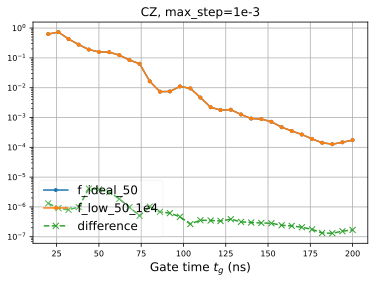

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
# ax.plot(cz_se['tg'], 10**f_3us_50, '.-',  label=r'f_3us_50')
# ax.plot(cz_se['tg'], 10**f_30us_50, '.-',  label=r'f_30us_50')
# ax.plot(cz_se['tg'], 10**f_170us_50, '.-',  label=r'f_170us_50')
# ax.plot(cz_se['tg'], 10**f_ideal_1000, '.-',  label=r'f_ideal_1000')

# ax.plot(cz_se['tg'], 10**f_short_50, '.-',  label=r'f_short_50')
# plt.plot(cz_se['tg'], np.abs(10**f_ideal_1000 - 10**f_short_50) , 'x--', label=r'difference')

# ax.plot(cz_se['tg'], 10**f_short_100, '.-',  label=r'f_short_100')
# plt.plot(cz_se['tg'], np.abs(10**f_ideal_1000 - 10**f_short_100) , 'x--', label=r'difference')

# ax.plot(cz_se['tg'], 10**f_short_150, '.-',  label=r'f_short_150')
# plt.plot(cz_se['tg'], np.abs(10**f_ideal_1000 - 10**f_short_150) , 'x--', label=r'difference')

# ax.plot(cz_se['tg'], 10**f_short_200, '.-',  label=r'f_short_200')
# plt.plot(cz_se['tg'], np.abs(10**f_ideal_1000 - 10**f_short_200) , 'x--', label=r'difference')

ax.plot(cz_se['tg'], 10**f_ideal_50, '.-',  label=r'f_ideal_50')
# plt.plot(cz_se['tg'], np.abs(10**f_ideal_1000 - 10**f_ideal_50) , 'x--', label=r'difference')

# ax.plot(cz_se['tg'], 10**f_ideal_100, '.-',  label=r'f_ideal_100')
# plt.plot(cz_se['tg'], np.abs(10**f_ideal_1000 - 10**f_ideal_100) , 'x--', label=r'difference')

# ax.plot(cz_se['tg'], 10**f_ideal_150, '.-',  label=r'f_ideal_150')
# plt.plot(cz_se['tg'], np.abs(10**f_ideal_1000 - 10**f_ideal_150) , 'x--', label=r'difference')

# ax.plot(cz_se['tg'], 10**f_ideal_200, '.-',  label=r'f_ideal_200')
# plt.plot(cz_se['tg'], np.abs(10**f_ideal_1000 - 10**f_ideal_200) , 'x--', label=r'difference')

# ax.plot(cz_se['tg'], 10**f_low_100_1e4, '.-',  label=r'f_low_100_1e4')
# plt.plot(cz_se['tg'], np.abs(10**f_low_100_1e4 - 10**f_ideal_100) , 'x--', label=r'difference')

ax.plot(cz_se['tg'], 10**f_low_50_1e4, '.-',  label=r'f_low_50_1e4')
plt.plot(cz_se['tg'], np.abs(10**f_low_50_1e4 - 10**f_ideal_50) , 'x--', label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CZ, max_step=1e-3', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [3]:
f_ideal_50 = np.array([
-0.44036360317460355, -1.3100641463931224, -2.9694003186598765, -3.6082666505498775 ,
-3.956701261590536 ,
])
f_170us_50 = np.array([
-0.44031246, -1.30922452, -2.91170534, -3.36896602 ,
-3.48170005 ,
])
f_30us_50 = np.array([
-0.44010660, -1.30577456, -2.75563155, -2.96519146 ,
-2.94198986 ,
])
f_3us_50 = np.array([
-0.43784564, -1.26977020, -2.12283825, -2.08662030 ,
-2.00431118 ,
])

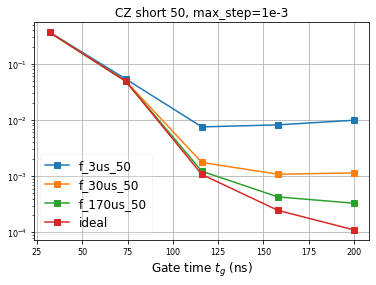

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_3us_50, 's-',  label=r'f_3us_50')
ax.plot(tg_list, 10**f_30us_50, 's-',  label=r'f_30us_50')
ax.plot(tg_list, 10**f_170us_50, 's-',  label=r'f_170us_50')
ax.plot(tg_list, 10**f_ideal_50, 's-',  label=r'ideal')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CZ short 50, max_step=1e-3', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### CZ Infidelity convergence on truncation (short_500_500_detune=0.023)

max_step=1e-3

In [11]:
n_truc_list = np.arange(50, 401, 50) 
f_short_500_500_deune1 = np.array([
[-0.44036360318129886, -1.3100641466806289, -2.9694003183501323, -3.608266650884425, -3.956701262270901] ,
[-0.4257042491959237, -1.329435098100823, -2.960405744067241, -3.617804505515683, -3.9499619403541577] ,
[-0.4266640276827752, -1.32219806605268, -2.8532870206082377, -3.6021031333080042, -3.9502491916064613] ,
[-0.4097213201091437, -1.3223819587508325, -2.831108805940601, -3.54289712263122, -3.9499726186882747] ,
[-0.40767590461627967, -1.3191434541124754, -2.817988096664284, -3.532108184323284, -3.948755641708353] ,
[-0.4032815345337876, -1.3222886263510543, -2.8245581519359684, -3.527181885352678, -3.948626521288063] ,
[-0.40236257936434566, -1.3227183722567524, -2.8280901149182895, -3.525549568320215, -3.9487523814188963] ,
[-0.40187166509112715, -1.322613179335865, -2.8284455811268687, -3.5256631353781933, -3.948820249268974] ,
])

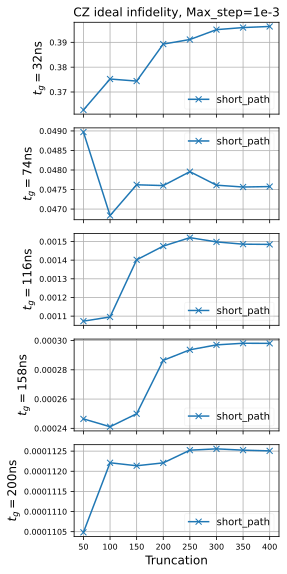

In [5]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(n_truc_list, 10**f_short_500_500_deune1[:,i], 'x-', label=fr'short_path')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=10)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns', fontsize=12)
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-3', fontsize=12)
plt.tight_layout()

### CZ Infidelity convergence on truncation (short_1000_400)

max_step=1e-3

In [6]:
n_truc_list = [ 75, 100, 125, 150, 175, 200]
n_truc_list_long = np.arange(75, 401, 25)
f_short = np.array([
[-0.41152054788734743, -1.3095661711664661, -2.960470769994891, -3.6026816095267233, -3.962572442062969], 
[-0.399606146876086, -1.3284484534871313, -2.950264518775447, -3.609822032921169, -3.9571201256640913], 
[-0.431585781170284, -1.3275099285920255, -2.961193529028784, -3.6176349709399047, -3.949878893216806], 
[-0.42501190989341464, -1.3267155882929713, -2.960571660257597, -3.617748175797952, -3.9501512756646733], 
[-0.41819457586869957, -1.3238399580915696, -2.863614013584925, -3.559120873022104, -3.937183521726618], 
[-0.40516014199221906, -1.3231194651505827, -2.834435324317289, -3.5577324603403446, -3.9372253241632347], 
[-0.4065678014546426, -1.3231972085389205, -2.8352223770340252, -3.546008094141041, -3.9441391061939237],

[-0.40393506, -1.32217545, -2.83678423, -3.53217227, -3.94872466] ,
[-0.4101953, -1.31879167, -2.81964688, -3.53142558, -3.94879329] ,
[-0.4042536, -1.32230425, -2.824841, -3.5282737, -3.94856166] ,
[-0.40381833, -1.32232709, -2.82346449, -3.52764125, -3.94862964] ,
[-0.40364508, -1.32269418, -2.82802328, -3.52532304, -3.94874784] ,
[-0.40327911, -1.32269083, -2.82830767, -3.52511966, -3.94880356] ,
[-0.40336342, -1.32259324, -2.82864149, -3.52597175, -3.94886785] ,
[-0.40336062, -1.32259485, -2.82856831, -3.52549741, -3.94891557] ,
])
f_all = np.array([
[-0.38644814, -1.81451339, -2.00755269, -2.64681655, -3.00084123] ,
[-0.43733365, -1.31811183, -2.9610364, -3.61813966, -3.94897779] ,
[-0.42991497, -1.32768107, -2.95953791, -3.61930989, -3.94909778] ,
[-0.44424117, -1.32255672, -2.84839748, -3.61779178, -3.95013914] ,
[-0.40213422, -1.32368489, -2.82744192, -3.617749, -3.95020103] ,
[-0.41361535, -1.32291949, -2.83443614, -3.58105046, -3.9502406] ,
[-0.41118844, -1.32270399, -2.836374, -3.58022109, -3.95028868] ,

[-0.40508128, -1.32205044, -2.83409176, -3.53333988, -3.9487286] ,
[-0.41076469, -1.32097046, -2.82127538, -3.53239684, -3.94880255] ,
[-0.40378526, -1.3223243, -2.82441675, -3.527401, -3.94861131] ,
[-0.40363823, -1.32233913, -2.82351018, -3.52761724, -3.94862743] ,
[-0.40368751, -1.32267694, -2.82810289, -3.52524752, -3.9487476] ,
[-0.40331276, -1.32255502, -2.8286146, -3.52532822, -3.94879605] ,
[-0.40337145, -1.32258397, -2.82860881, -3.52611951, -3.94886747] ,
[-0.40336062, -1.32259485, -2.82856831, -3.52549741, -3.94891557] ,
])
f_lowest = np.array([
[-0.36554139, -0.47500736, -0.41158606, -0.42936589, -0.41295294,-0.4122852 , -0.40229208],
[-1.19796746, -1.33821346, -1.31985603, -1.32375727, -1.32196245,-1.32044417, -1.32157514],
[-2.65516135, -2.94662484, -2.9422268 , -2.94682095, -2.93623823,-2.82115399, -2.83456922],
[-3.32489203, -3.62211513, -3.58514059, -3.58699464, -3.56714873,-3.53632105, -3.53659151],
[-3.75810098, -3.94816936, -3.93846721, -3.93881822, -3.94919605,-3.94893679, -3.94897473]
        ])
f_ideal_1000 = np.array([
-0.40215530875591887, -1.3226609064874149, -2.8283848283603117, -3.5222117329875666 ,
-3.9493951402836407 ,
])

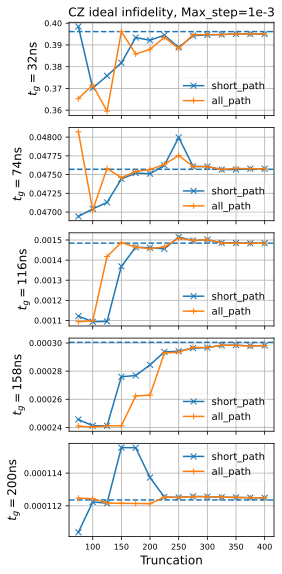

In [7]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    # ax[i].axhline(y=10**f_ideal_1000[i], linestyle='--', label=fr'1000 states')
    ax[i].axhline(y=10**f_ideal_1000[i], linestyle='--')
    # ax[i].plot(n_truc_list, 10**f_lowest[i, 1:], '.-', label=fr'lowest_states')
    ax[i].plot(n_truc_list_long, 10**f_short[1:,i], 'x-', label=fr'short_path')
    ax[i].plot(n_truc_list_long, 10**f_all[1:,i], '+-', label=fr'all_path')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=10)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns', fontsize=12)
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-3', fontsize=12)
plt.tight_layout()

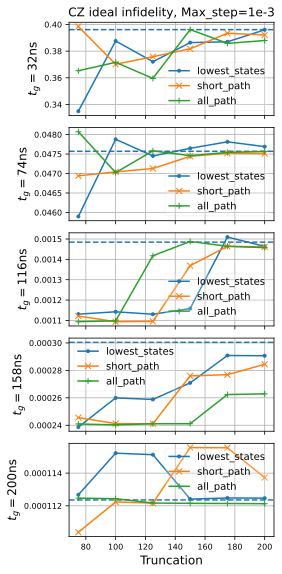

In [ ]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    # ax[i].axhline(y=10**f_ideal_1000[i], linestyle='--', label=fr'1000 states')
    ax[i].axhline(y=10**f_ideal_1000[i], linestyle='--')
    ax[i].plot(n_truc_list, 10**f_lowest[i, 1:], '.-', label=fr'lowest_states')
    ax[i].plot(n_truc_list, 10**f_short[1:,i], 'x-', label=fr'short_path')
    ax[i].plot(n_truc_list, 10**f_all[1:,i], '+-', label=fr'all_path')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=10)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns', fontsize=12)
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-3', fontsize=12)
plt.tight_layout()

### CZ Infidelity convergence on truncation

max_step=1e-3

In [49]:
f_ideal_1000 = np.array([
-0.40215530875591887, -1.3226609064874149, -2.8283848283603117, -3.5222117329875666 ,
-3.9493951402836407 ,
])
f_ideal_500 = np.array([
-0.40190347098081924, -1.3226132149988326, -2.828124341813371, -3.524121435451491 ,
-3.9489156781770216 ,
])
f_ideal_200 = np.array([
-0.4022920793018655, -1.3215751413387333, -2.8345692209828206, -3.5365915050345276 ,
-3.9489747294329547 ,
])
f_ideal_175 = np.array([
-0.41228519521571433, -1.320444170468342, -2.8211539949966906, -3.5363210453336222 ,
-3.9489367897944523 ,
])
f_ideal_150 = np.array([
-0.41295294308784114, -1.3219624539313637, -2.9362382306487387, -3.5671487339539234 ,
-3.9491960491181155 ,
])
f_ideal_125 = np.array([
-0.429365888515395, -1.3237572669618043, -2.9468209518929065, -3.5869946398447072 ,
-3.9388182247039696 ,
])
f_ideal_100 = np.array([
-0.4115860612962274, -1.3198560293788524, -2.94222680424175, -3.5851405891926054 ,
-3.938467212637457 ,
])
f_ideal_75 = np.array([
-0.47500736108392566, -1.338213458150725, -2.946624840304518, -3.62211512653724 ,
-3.9481693559895814 ,
])
f_ideal_50 = np.array([
-0.365541388362558, -1.1979674636067066, -2.655161346452038, -3.3248920336245815 ,
-3.7581009800964025 ,
])
f_ideal_1e3 = np.column_stack((f_ideal_50, f_ideal_75, f_ideal_100, f_ideal_125, 
                               f_ideal_150, f_ideal_175, f_ideal_200, f_ideal_500, f_ideal_1000))
truc = [ 75, 100, 125, 150, 175, 200, 500, 1000]


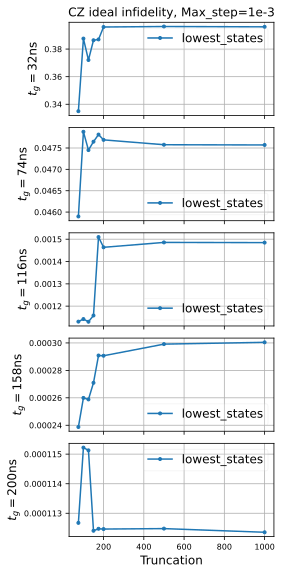

In [50]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e3[i, 1:], '.-', label=fr'lowest_states')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns', fontsize=12)
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-3', fontsize=12)
plt.tight_layout()

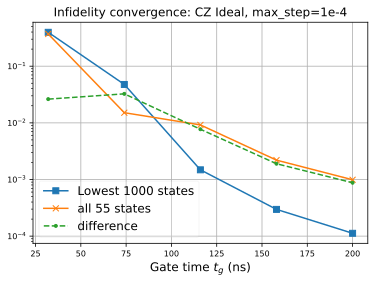

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000, 's-',  label=r'Lowest 1000 states')
# ax.plot(tg_list, 10**f_ideal_200all, 'x-',  label=r'all 200 states')
# ax.plot(tg_list, np.abs(10**f_ideal_200all - 10**f_ideal_1000), '.--',  label=r'difference')
# ax.plot(tg_list, 10**f_ideal_100all, 'x-',  label=r'all 100 states')
# ax.plot(tg_list, np.abs(10**f_ideal_100all - 10**f_ideal_1000), '.--',  label=r'difference')
ax.plot(tg_list, 10**f_ideal_55all, 'x-',  label=r'all 55 states')
ax.plot(tg_list, np.abs(10**f_ideal_55all - 10**f_ideal_1000), '.--',  label=r'difference')
# ax.plot(tg_list, 10**f_ideal_55hand, 'x-',  label=r'hand 55 states')
# ax.plot(tg_list, np.abs(10**f_ideal_55hand - 10**f_ideal_1000), '.--',  label=r'difference')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### CZ Infidelity convergence on truncation

max_step=1e-4

In [ ]:
f_ideal_1000 = np.array([
-0.4021448542569617, -1.322630044450615, -2.8292207939498746, -3.5275890997936 ,
-3.949321454120114 ,
])
f_ideal_500 = np.array([
-0.4019024311954381, -1.3225689542270946, -2.8290068464858975, -3.527383190402311 ,
-3.9490553958799968 ,
])
f_ideal_200 = np.array([
-0.40231840173270494, -1.3215409903668713, -2.834576276147882, -3.536724638506567 ,
-3.948964223504374 ,
])
f_ideal_100 = np.array([
-0.4115791900644499, -1.3198497484563945, -2.942236121065928, -3.5852211042087814 ,
-3.9385615217377574 ,
])
f_ideal_55 = np.array([
-0.45025287595319985, -1.3257510272715618, -2.964305513310644, -3.619544687982036 ,
-3.9477218664684277 ,
])
f_ideal_50 = np.array([
-0.3655405764342905, -1.1979709249154762, -2.6552301504055555, -3.3251147403994836 ,
-3.7585441100976005 ,
])
f_ideal_200all = np.array([
-0.41121313361134304, -1.3226723548736532, -2.8362380292688596, -3.581491348170476 ,
-3.950496841904949 ,
])
f_ideal_100all = np.array([
-0.42990739486664165, -1.3277134086419864, -2.959479334161531, -3.6198621123898262 ,
-3.9493747206563383 ,
])
f_ideal_55all = np.array([
-0.4318735728509982, -1.8212556529595825, -2.0369030448780947, -2.6586659804851434 ,
-3.004915350805105 ,
])
f_ideal_55hand = np.array([
-0.45025287595319985, -1.3257510272715618, -2.964305513310644, -3.619544687982036 ,
-3.9477218664684277 ,
])

truc = [50, 100, 200, 500, 1000]
f_ideal_1e4 = np.column_stack((f_ideal_50, f_ideal_100, f_ideal_200, f_ideal_500, f_ideal_1000))

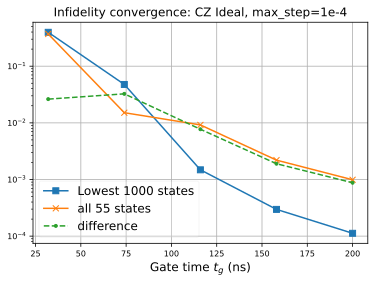

In [16]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000, 's-',  label=r'Lowest 1000 states')
# ax.plot(tg_list, 10**f_ideal_200all, 'x-',  label=r'all 200 states')
# ax.plot(tg_list, np.abs(10**f_ideal_200all - 10**f_ideal_1000), '.--',  label=r'difference')
# ax.plot(tg_list, 10**f_ideal_100all, 'x-',  label=r'all 100 states')
# ax.plot(tg_list, np.abs(10**f_ideal_100all - 10**f_ideal_1000), '.--',  label=r'difference')
ax.plot(tg_list, 10**f_ideal_55all, 'x-',  label=r'all 55 states')
ax.plot(tg_list, np.abs(10**f_ideal_55all - 10**f_ideal_1000), '.--',  label=r'difference')
# ax.plot(tg_list, 10**f_ideal_55hand, 'x-',  label=r'hand 55 states')
# ax.plot(tg_list, np.abs(10**f_ideal_55hand - 10**f_ideal_1000), '.--',  label=r'difference')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

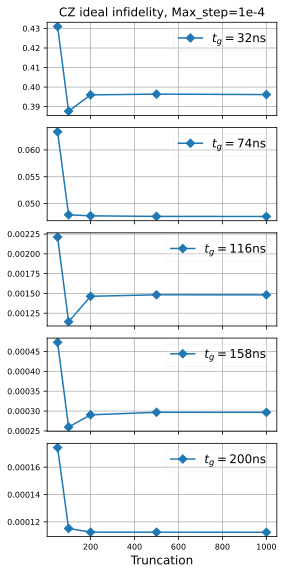

In [4]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e4[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-4', fontsize=12)
plt.tight_layout()

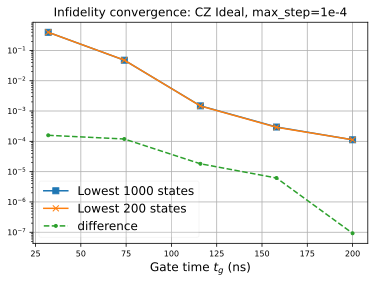

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000, 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_ideal_200, 'x-',  label=r'Lowest 200 states')
ax.plot(tg_list, np.abs(10**f_ideal_200 - 10**f_ideal_1000), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent